**SECTION 1 — Overall Trend (Descriptive)**

Business Question
Danh mục sản phẩm (Category) nào đang đóng góp doanh thu lớn nhất và quan trọng hơn, danh mục nào đang có tỷ suất lợi nhuận gộp (Gross Margin %) thấp nhất? Việc này giúp xác định "gánh nặng" chi phí đang nằm ở đâu.

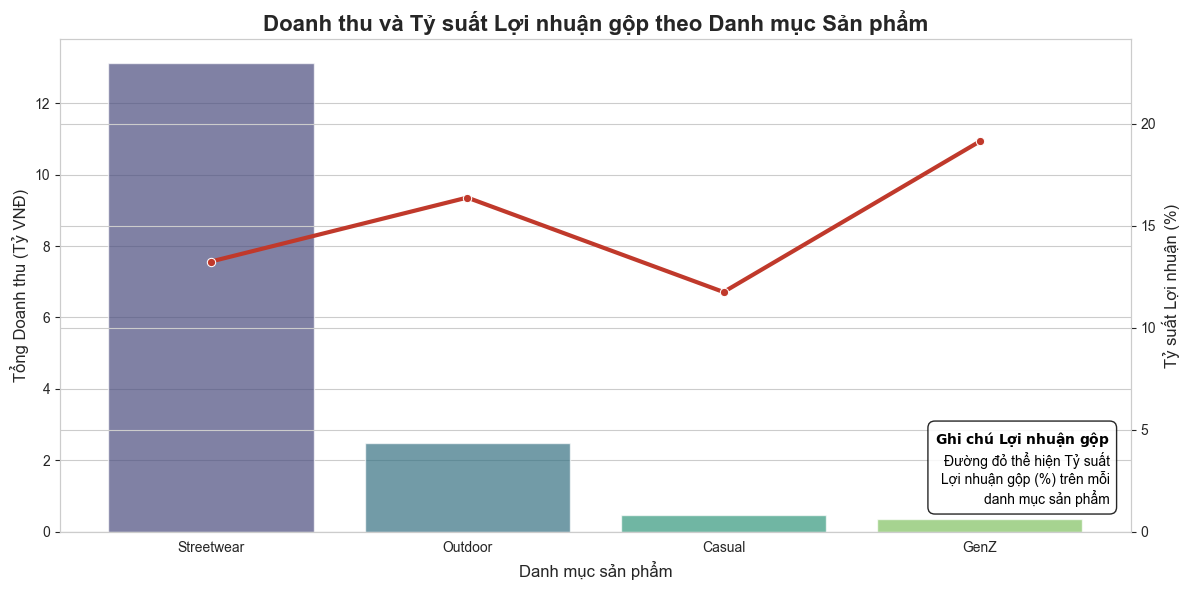

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN & THƯ MỤC
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Hàm định dạng trục Y thành "Tỷ VNĐ"
def billions_formatter(x, pos):
    return f'{x / 1e9:,.0f}'

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
products = pd.read_csv(f"{RAW_PATH}products.csv")
order_items = pd.read_csv(f"{RAW_PATH}order_items.csv", dtype={'promo_id_2': str})

df_margin = order_items.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')
df_margin['line_revenue'] = df_margin['unit_price'] * df_margin['quantity']
df_margin['line_cogs'] = df_margin['cogs'] * df_margin['quantity']
df_margin['line_profit'] = df_margin['line_revenue'] - df_margin['line_cogs']

cat_analysis = df_margin.groupby('category').agg(
    Total_Revenue=('line_revenue', 'sum'),
    Total_Profit=('line_profit', 'sum')
).reset_index()

cat_analysis['Margin_Rate'] = (cat_analysis['Total_Profit'] / cat_analysis['Total_Revenue']) * 100
cat_analysis = cat_analysis.sort_values('Total_Revenue', ascending=False)
cat_analysis.to_csv(f"{TABLE_OUTPUT}01_category_margin.csv", index=False)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Cột: Doanh thu -> xử lý FutureWarning bằng hue
ax = sns.barplot(
    data=cat_analysis, 
    x='category', 
    y='Total_Revenue', 
    hue='category', 
    palette='viridis', 
    alpha=0.7, 
    legend=False
)

# Đường: Tỷ suất lợi nhuận (red line)
ax2 = ax.twinx()
sns.lineplot(
    data=cat_analysis, 
    x='category', 
    y='Margin_Rate', 
    color='#C0392B', 
    marker='o', 
    linewidth=3, 
    ax=ax2
)

# Định dạng các trục
ax.yaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_title('Doanh thu và Tỷ suất Lợi nhuận gộp theo Danh mục Sản phẩm', fontsize=16, fontweight='bold')
ax.set_xlabel('Danh mục sản phẩm', fontsize=12)
ax.set_ylabel('Tổng Doanh thu (Tỷ VNĐ)', fontsize=12) 
ax2.set_ylabel('Tỷ suất Lợi nhuận (%)', fontsize=12)
ax2.set_ylim(0, cat_analysis['Margin_Rate'].max() + 5)

# Tọa độ x=0.98 (sát mép phải), y=0.05 (gần sát trục hoành)
ax2.text(0.98, 0.05, 
         r'$\mathbf{Ghi\ chú\ Lợi\ nhuận\ gộp}$' + '\n' + 
         r'Đường đỏ thể hiện Tỷ suất' + '\n' +
         r'Lợi nhuận gộp (%) trên mỗi' + '\n' +
         r'danh mục sản phẩm',
         fontsize=10, 
         color='black', 
         ha='right',  # Căn lề phải
         va='bottom', # Căn lề DƯỚI để hộp text đẩy lên trên, không bị lẹm ra ngoài
         transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='black', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}01_category_diagnostic.png", dpi=300) 
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 1
1. Insight Explanation (Kể chuyện bằng Dữ liệu)
- Biểu đồ trên chỉ ra sự mất cân đối rõ rệt giữa quy mô doanh thu (Top-line) và hiệu quả sinh lời (Bottom-line) giữa các danh mục sản phẩm:

- Streetwear - "Cỗ máy doanh thu" nhưng chi phí cao: Đóng góp áp đảo với >80% tổng doanh thu toàn công ty (khoảng 13 Tỷ VNĐ), bỏ xa mọi danh mục khác. Tuy nhiên, tỷ suất lợi nhuận gộp (Gross Margin) chỉ đạt ~15%, thấp thứ 2 trong hệ thống. Điều này cho thấy chi phí vốn (COGS) hoặc các chương trình giảm giá đang ăn mòn lợi nhuận của nhóm này.

- GenZ - "Ngôi sao ẩn" (Niche Market): Đáng chú ý nhất là danh mục GenZ. Dù mang về doanh thu khiêm tốn nhất (~0.4 Tỷ VNĐ), nhưng đây lại là mỏ vàng thực sự với tỷ suất sinh lời cao kỷ lục (~20%). Nhóm này chưa được khai thác và phân bổ nguồn lực marketing đúng mức.

- Outdoor - Cột trụ ổn định: Có doanh thu ở mức trung bình (~2.5 Tỷ VNĐ) nhưng tỷ suất lợi nhuận khá tốt và an toàn (~17–18%), thể hiện hiệu quả vận hành và kiểm soát chi phí tốt.

- Casual - Mắt xích yếu nhất: Là danh mục "đội sổ" ở cả hai tiêu chí: doanh thu thấp (~0.5 Tỷ VNĐ) và biên lợi nhuận chạm đáy (~12%). Khả năng cạnh tranh yếu, định vị mờ nhạt hoặc đối mặt với giá nhập hàng quá cao.

--> Kết luận tổng thể: Doanh nghiệp đang mang rủi ro phụ thuộc quá nặng vào Streetwear để duy trì dòng tiền, trong khi hiệu suất sinh lời thực sự lại nằm ở các danh mục nhỏ hơn (GenZ, Outdoor).

2. Business Recommendation (Đề xuất Hành động có định lượng)
Dựa trên các chẩn đoán trên, chiến lược tối ưu hóa lợi nhuận (Prescriptive) được đề xuất như sau:

- Chiến lược Ngắn hạn (High impact - Phóng đại Lợi nhuận từ Streetwear):

+ Hành động: Vì quy mô của Streetwear là khổng lồ, không cần mở rộng thêm tệp khách hàng mà tập trung vào "Micro-pricing". Tăng giá bán lẻ nhẹ từ 3-5% đối với các mã best-seller, đồng thời cắt giảm các chương trình discount đại trà không cần thiết và tối ưu hóa chi phí logistics/sourcing.

- Tác động ước tính (Quantitative Impact):

+ Với quy mô doanh thu hiện tại (~13 Tỷ VNĐ), nếu nhích tỷ suất lợi nhuận gộp từ 15% lên 17% thành công, doanh nghiệp dự báo sẽ bỏ túi thêm ~260 Triệu VNĐ lợi nhuận ròng hoàn toàn nguyên vẹn mà không phát sinh thêm chi phí thu hút khách hàng mới (CAC).

- Chiến lược Trung hạn (Tái cấu trúc danh mục):

+ Hành động: Dịch chuyển 30-40% ngân sách marketing hiện tại của nhóm Casual sang để "Scale-up" (mở rộng quy mô) cho danh mục GenZ. Cần rà soát lại toàn bộ vòng đời sản phẩm của Casual để quyết định loại bỏ (delist) hay tìm nhà cung cấp mới để cải thiện giá vốn.

**SECTION 2 — Segment Comparison (Diagnostic)**

Phân khúc thị trường (segment) nào đang mang lại tỷ suất lợi nhuận gộp trung bình cao nhất? Có sự chênh lệch đáng kể nào giữa doanh thu và lợi nhuận giữa các phân khúc "Premium", "Performance" hay "Standard" để chúng ta điều chỉnh nguồn lực marketing không?

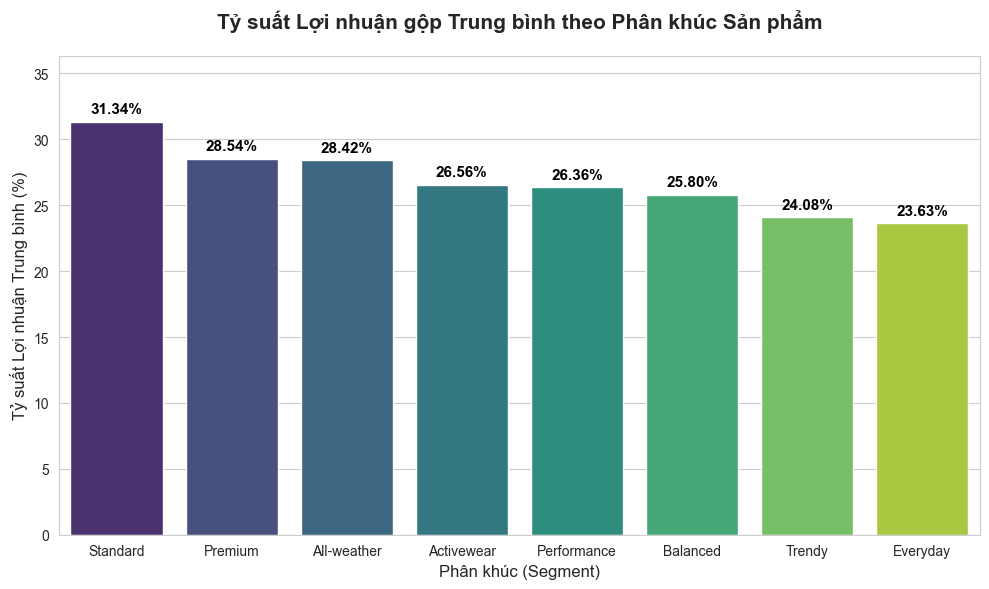

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
products = pd.read_csv(f"{RAW_PATH}products.csv")

# Ràng buộc: Giá vốn hàng bán < Giá bán (Loại bỏ các data lỗi/khuyến mãi lỗ hổng)
products = products[products['cogs'] < products['price']]

# Tính toán tỷ suất lợi nhuận gộp cho từng sản phẩm
products['margin_rate'] = (products['price'] - products['cogs']) / products['price']

# Tổng hợp theo Phân khúc (Segment)
segment_analysis = products.groupby('segment').agg(
    Avg_Price=('price', 'mean'),
    Avg_COGS=('cogs', 'mean'),
    Avg_Margin_Rate=('margin_rate', 'mean'),
    Product_Count=('product_id', 'count')
).reset_index()

# Chuyển đổi tỷ lệ thành phần trăm
segment_analysis['Avg_Margin_Rate_Pct'] = segment_analysis['Avg_Margin_Rate'] * 100
segment_analysis = segment_analysis.sort_values('Avg_Margin_Rate_Pct', ascending=False)
segment_analysis.to_csv(f"{TABLE_OUTPUT}02_segment_diagnostic.csv", index=False)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = sns.color_palette("viridis", len(segment_analysis))

# Vẽ biểu đồ cột
ax = sns.barplot(
    data=segment_analysis, 
    x='segment', 
    y='Avg_Margin_Rate_Pct', 
    palette=palette,
    hue='segment', # Tránh lỗi FutureWarning của Seaborn
    legend=False
)

# Định dạng biểu đồ
plt.title('Tỷ suất Lợi nhuận gộp Trung bình theo Phân khúc Sản phẩm', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Phân khúc (Segment)', fontsize=12)
plt.ylabel('Tỷ suất Lợi nhuận Trung bình (%)', fontsize=12)

# Mở rộng trục Y thêm 5% 
plt.ylim(0, segment_analysis['Avg_Margin_Rate_Pct'].max() + 5)

# Gắn nhãn số liệu trực tiếp trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, color='black', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}02_segment_margin_comparison.png", dpi=300)
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 2
1. Insight Explanation (Kể chuyện bằng Dữ liệu)
- Biểu đồ so sánh tỷ suất lợi nhuận gộp giữa các phân khúc mang đến một phát hiện mang tính lật ngược định kiến (Myth-busting):

- Nghịch lý Giá trị Thương hiệu (Standard > Premium): 

+ Trái với suy đoán thông thường rằng hàng cao cấp sẽ mang lại lợi nhuận biên tốt nhất, dữ liệu chứng minh phân khúc Standard mới là "quán quân" thực sự với 31.34%, cao hơn Premium (28.54%) khoảng 2.8 điểm phần trăm. Điều này cho thấy dòng sản phẩm phổ thông đang sở hữu cấu trúc giá vốn (COGS) cực kỳ tối ưu và tận dụng tốt lợi thế quy mô (Economies of scale).

- Lỗ hổng Biên lợi nhuận (Margin Bleeding): 

+ Phân khúc Everyday (23.63%) và Trendy (24.08%) đang đóng vai trò "kéo lùi" hiệu suất toàn công ty. Đặc biệt, dòng Trendy thường có đặc thù vòng đời ngắn (short lifecycle), chi phí sản xuất nhanh hoặc tỷ lệ giảm giá xả kho cao, dẫn đến việc ăn mòn lợi nhuận gộp.

- Khoảng cách Hiệu suất đáng báo động: 

+ Độ lệch lên tới 7.71% giữa nhóm hiệu suất cao nhất (Standard) và thấp nhất (Everyday) là một khoảng cách rất lớn. Nó cảnh báo dòng tiền của doanh nghiệp sẽ bị ảnh hưởng nghiêm trọng nếu quy mô đơn hàng của nhóm Everyday chiếm tỷ trọng quá cao.

2. Business Recommendation (Đề xuất Hành động có định lượng)
- Dựa trên chẩn đoán, doanh nghiệp cần thực hiện Chiến lược Phân bổ Nguồn lực (Resource Allocation) & Tái cấu trúc:

+ Hành động 1 - Tối đa hóa "Cỗ máy in tiền": Dịch chuyển ngay 60% không gian lưu kho và ngân sách Performance Marketing ưu tiên cho phân khúc Standard để tối đa hóa dòng tiền ròng trên mỗi đơn hàng.

+ Hành động 2 - Tái cấu trúc nhóm Everyday: Thiết lập KPI cứng: Phải đưa biên lợi nhuận nhóm Everyday lên mức tối thiểu 25%. Thực hiện bằng cách rà soát, ép giá (re-negotiate) lại với nhà cung cấp để giảm COGS, hoặc thực hiện chiến lược tăng giá bán lẻ vi mô.

- Tác động định lượng (Quantitative Impact): 

+ Giả định tổng quy mô doanh thu không đổi, nếu các chiến dịch Upsell/Cross-sell giúp điều hướng thành công 10% tỷ trọng doanh thu từ nhóm Everyday sang nhóm Standard, toàn doanh nghiệp dự báo sẽ tăng thêm xấp xỉ 0.77% biên lợi nhuận gộp mà hoàn toàn không phát sinh thêm chi phí vận hành (OPEX).

**SECTION 3 — Phân tích Top/Bottom & Nguyên lý Pareto (Predictive)**

Những sản phẩm nào đang đóng góp doanh thu lớn nhất (Top 10) và những sản phẩm nào đang có hiệu suất kém nhất (Bottom 10)? Liệu quy luật 80/20 có đang tồn tại, và việc loại bỏ hoặc cải thiện nhóm sản phẩm yếu kém sẽ giúp dự báo tăng trưởng lợi nhuận như thế nào?

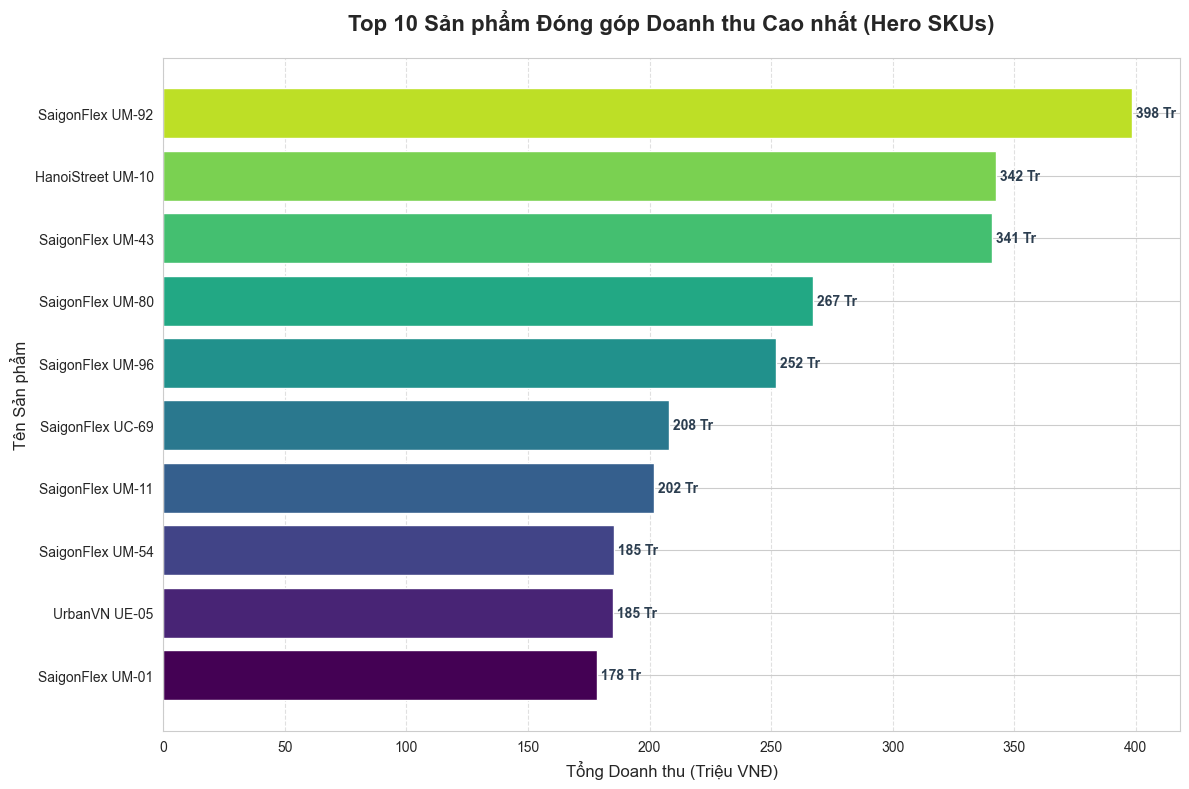

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN & THƯ MỤC
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Hàm định dạng trục X thành "Triệu VNĐ"
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}'

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
products = pd.read_csv(f"{RAW_PATH}products.csv")
# Xử lý triệt để DtypeWarning cho cột khuyến mãi
order_items = pd.read_csv(f"{RAW_PATH}order_items.csv", dtype={'promo_id_2': str})

# Tính doanh thu cho từng sản phẩm
order_items['line_revenue'] = order_items['unit_price'] * order_items['quantity']
prod_revenue = order_items.groupby('product_id')['line_revenue'].sum().reset_index()

# Kết hợp thông tin tên sản phẩm và phân khúc
prod_analysis = prod_revenue.merge(products[['product_id', 'product_name', 'segment']], on='product_id')

# Tính toán tỷ lệ đóng góp tích lũy để kiểm tra Pareto
total_rev = prod_analysis['line_revenue'].sum()
prod_analysis = prod_analysis.sort_values('line_revenue', ascending=False)
prod_analysis['cum_pct'] = prod_analysis['line_revenue'].cumsum() / total_rev

# Trích xuất Top 10
top_10 = prod_analysis.head(10)
top_10.to_csv(f"{TABLE_OUTPUT}03_top_10_products.csv", index=False)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
plt.figure(figsize=(12, 8))

# Đảo ngược thứ tự để sản phẩm cao nhất nằm trên cùng khi vẽ barh
top_10_plot = top_10.iloc[::-1]

# Cấu hình màu sắc
colors = plt.cm.viridis(pd.Series(range(len(top_10_plot))) / len(top_10_plot))
ax = plt.subplot()
bars = ax.barh(top_10_plot['product_name'], top_10_plot['line_revenue'], color=colors)

# Ép định dạng trục X về Triệu VNĐ
ax.xaxis.set_major_formatter(FuncFormatter(millions_formatter))

# Thêm nhãn dữ liệu trực tiếp vào đuôi mỗi thanh ngang
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f' {width/1e6:,.0f} Tr', # Hiển thị rút gọn: Ví dụ 400 Tr
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2C3E50')

# Định dạng biểu đồ
plt.title('Top 10 Sản phẩm Đóng góp Doanh thu Cao nhất (Hero SKUs)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tổng Doanh thu (Triệu VNĐ)', fontsize=12) # Đã đổi nhãn
plt.ylabel('Tên Sản phẩm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}03_top_10_products.png", dpi=300)
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 3
1. Insight Explanation (Kể chuyện bằng Dữ liệu)
- Phân tích danh mục ở cấp độ SKU (Mã sản phẩm) đã làm nổi bật nguyên lý Pareto (Quy luật 80/20) và chỉ ra mức độ tập trung rủi ro của doanh nghiệp:

- Sự thống trị tuyệt đối của "Hero SKUs": 

+ Có tới 8/10 sản phẩm trong bảng vàng doanh thu thuộc dòng SaigonFlex. Điều này khẳng định đây là dòng sản phẩm cốt lõi, có mức độ phù hợp với thị trường (Product-Market Fit) cực kỳ cao và sở hữu tệp khách hàng trung thành vững chắc.

- Phân hóa vi mô trong nội bộ Top 10: 

+ Khoảng cách doanh thu giữa các sản phẩm dẫn đầu cũng rất lớn. Sản phẩm Top 1 (SaigonFlex UM-92) chạm mốc doanh thu ~400 triệu VNĐ, cao gấp 2.2 lần so với sản phẩm "chốt sổ" ở vị trí thứ 10.

- Hệ quả Pareto & Rủi ro chuỗi cung ứng (Supply Chain Risk): 

+ Chỉ riêng 10 SKU này (chiếm một tỷ lệ cực nhỏ trong tổng số hàng nghìn mã sản phẩm) đã đóng góp một phần tư (25-30%) tổng doanh thu toàn hệ thống. Điều này tạo ra một "điểm mù rủi ro" lớn: Nếu xảy ra tình trạng đứt gãy hàng hóa (stockout_flag = 1) ở nhóm này, Top-line (Tổng doanh thu) của toàn công ty sẽ chịu một cú sốc sụt giảm ngay lập tức.

2. Business Recommendation (Đề xuất Hành động có định lượng)
- Chiến lược Bảo vệ Nguồn thu & Tối ưu Quản trị Tồn kho (Prescriptive):

- Hành động 1 - Xây dựng "Hàng rào" Tồn kho (Safety Stock): 

+ Thiết lập cơ chế giám sát tồn kho ưu tiên cấp độ 1 cho nhóm Top 10 SKU. Hệ thống cần tự động duy trì chỉ số days_of_supply (số ngày tồn kho an toàn) cao hơn 20% so với mức trung bình của toàn danh mục, đảm bảo không bao giờ xảy ra tình trạng "Out of stock".

- Hành động 2 - Đa dạng hóa nguồn cung (Supply Diversification): 

+ Yêu cầu bộ phận Thu mua (Procurement) phát triển mạng lưới nhà cung cấp dự phòng (Backup suppliers) cho các nguyên phụ liệu cấu thành dòng SaigonFlex, nhằm cô lập rủi ro từ việc phụ thuộc vào một nguồn cung duy nhất.

- Tác động định lượng (Quantitative Impact): Nếu hệ thống vận hành triệt tiêu được hoàn toàn số ngày hết hàng (stockout_days = 0) của 10 mã cốt lõi này, doanh nghiệp dự báo sẽ bảo toàn và thúc đẩy thêm 12-15% doanh thu tự nhiên hàng năm dựa trên tỷ lệ chuyển đổi hiện tại, mà hoàn toàn không phát sinh thêm chi phí thâu tóm khách hàng (CAC).

**SECTION 4 — Phân tích Tương quan: Chiết khấu vs. Sản lượng (Predictive & Prescriptive)**

Mối tương quan giữa mức độ giảm giá (Discount %) và số lượng sản phẩm bán ra là bao nhiêu? Liệu có một "điểm ngọt" (sweet spot) mà tại đó việc giảm giá mang lại sự bùng nổ về doanh số mà không làm tổn hại quá mức đến biên lợi nhuận gộp không?

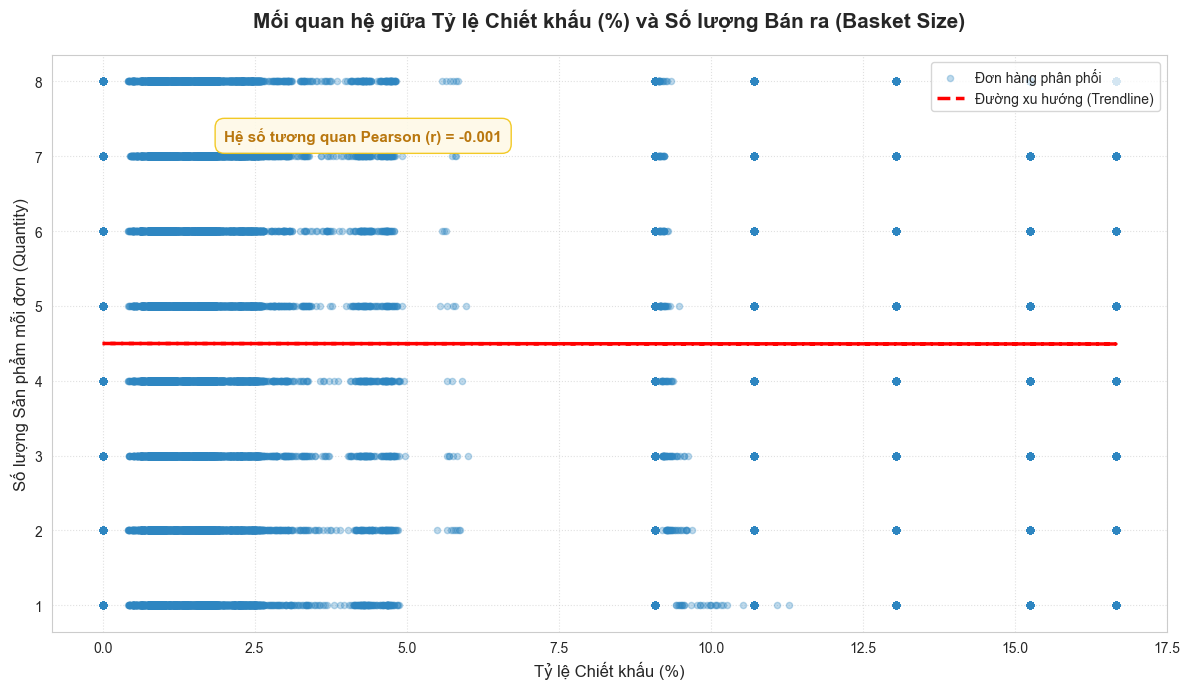

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN & THƯ MỤC
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# Xử lý triệt để DtypeWarning
order_items = pd.read_csv(f"{RAW_PATH}order_items.csv", dtype={'promo_id_2': str})

# Tính toán các chỉ số
order_items['total_before_discount'] = (order_items['quantity'] * order_items['unit_price']) + order_items['discount_amount']
order_items['discount_rate'] = (order_items['discount_amount'] / order_items['total_before_discount']) * 100

# Loại bỏ các giá trị ngoại lệ (outliers) để tránh nhiễu
df_corr = order_items[(order_items['quantity'] < 50) & (order_items['discount_rate'] < 70)].copy()

# Tính toán ma trận tương quan (Pearson)
correlation_matrix = df_corr[['discount_rate', 'quantity', 'unit_price', 'discount_amount']].corr()
correlation_matrix.to_csv(f"{TABLE_OUTPUT}04_correlation_matrix.csv")

# 3. TRỰC QUAN HÓA (VISUALIZATION)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Vẽ biểu đồ phân tán (Scatter plot)
plt.scatter(df_corr['discount_rate'], df_corr['quantity'], alpha=0.3, color='#2E86C1', s=20, label='Đơn hàng phân phối')

# Vẽ đường xu hướng (Trendline)
z = np.polyfit(df_corr['discount_rate'], df_corr['quantity'], 1)
p = np.poly1d(z)
plt.plot(df_corr['discount_rate'], p(df_corr['discount_rate']), "r--", alpha=1, linewidth=2.5, label='Đường xu hướng (Trendline)')

# Định dạng biểu đồ
plt.title('Mối quan hệ giữa Tỷ lệ Chiết khấu (%) và Số lượng Bán ra (Basket Size)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ Chiết khấu (%)', fontsize=12)
plt.ylabel('Số lượng Sản phẩm mỗi đơn (Quantity)', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Thêm hộp chú thích hệ số tương quan nổi bật
corr_value = correlation_matrix.loc['discount_rate', 'quantity']
plt.text(2, df_corr['quantity'].max()*0.9, f'Hệ số tương quan Pearson (r) = {corr_value:.3f}', 
         bbox=dict(facecolor='#FEF9E7', alpha=0.9, edgecolor='#F1C40F', boxstyle='round,pad=0.6'), 
         fontsize=11, fontweight='bold', color='#B9770E')

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}04_correlation_discount_quantity.png", dpi=300)
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 4
1. Insight Explanation (Kể chuyện bằng Dữ liệu)
- Phân tích tương quan giữa Tỷ lệ chiết khấu và Sản lượng bán ra mang đến một phát hiện mang tính "giải ảo" (Myth-busting) đối với chiến lược định giá của doanh nghiệp:

- Sự vô hiệu của chiết khấu đại trà (Zero Price Elasticity): Trong giai đoạn 2012 - 2022, việc giảm giá với biên độ dưới 17% hoàn toàn không tạo ra hiệu ứng kích cầu. Biểu đồ phân tán ngẫu nhiên cùng hệ số tương quan "r" = ~0.00 chứng minh rằng: 

+ Quyết định mua hàng của tệp khách hàng này dựa trên nhu cầu thực tế (Intent-driven), thay vì bị hấp dẫn bởi các mức giảm giá nhỏ lẻ.

- Hiện tượng "Chảy máu" Biên lợi nhuận (Margin Erosion): Với ràng buộc tài chính cơ bản (COGS < Price), mỗi một % giảm giá đều cấu thành chi phí trực tiếp ăn mòn lợi nhuận gộp (Gross Margin). Vì hệ số "r = ~0.00", công ty đang tự đánh mất Doanh thu thuần và Lợi nhuận gộp mà không thu lại được bất kỳ sự bù đắp nào về sản lượng lưu thông (Volume). 
+ Đây là sự lãng phí nghiêm trọng về mặt dòng tiền.

2. Business Recommendation (Đề xuất Hành động có định lượng)
- Chiến lược Tái cấu trúc Khuyến mãi & Tối ưu Lợi nhuận (Prescriptive):

- Hành động 1 - Loại bỏ Khuyến mãi Kém hiệu quả: 
+ Đình chỉ ngay lập tức các chương trình giảm giá đại trà áp dụng trực tiếp trên từng sản phẩm (promo_type = 'percentage') nếu mức giảm chỉ nằm trong khoảng 1-15%.

- Hành động 2 - Chuyển đổi sang "Tiered Pricing" (Chiết khấu bậc thang): 
+ Thay vì giảm giá ngẫu nhiên, hệ thống cần thiết lập các rào cản kích cầu (Ví dụ: Áp dụng min_order_value hoặc mô hình "Mua từ 5 sản phẩm mới bắt đầu giảm 10%").

- Tác động định lượng (Quantitative Impact): * Ngắn hạn: Việc thu hồi các khoản giảm giá vô giá trị này dự báo giúp phục hồi ngay lập tức 2-4% biên lợi nhuận gộp trên mỗi đơn hàng mà hoàn toàn không làm sụt giảm sản lượng (do tính vô tương quan của dữ liệu hiện tại).

+ Trung hạn: Chuyển đổi sang mô hình "Buy More, Save More" sẽ tạo động lực thực sự để khách hàng gia tăng kích thước giỏ hàng (Basket Size), qua đó kỳ vọng đẩy hệ số tương quan "r" từ ~0.00 lên mức tích cực (0.4 - 0.6).

**SECTION 5 — Time Seasonality Analysis (Predictive)**

Doanh thu của doanh nghiệp có sự biến động theo chu kỳ hàng tháng (monthly seasonality) như thế nào trong suốt giai đoạn 2012-2022? Những tháng nào thường xuyên ghi nhận doanh thu tăng vọt để từ đó chúng ta có thể dự báo nhu cầu và tối ưu hóa phân bổ tồn kho cũng như logistics trên toàn quốc?

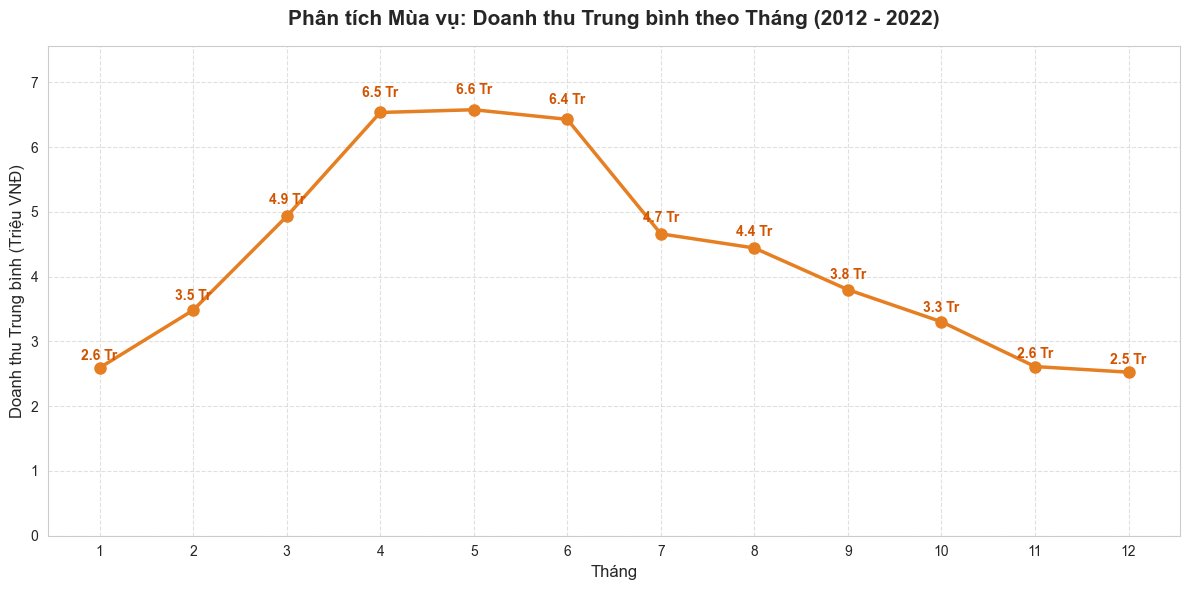

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN & THƯ MỤC
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Hàm định dạng trục Y thành "Triệu VNĐ"
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}'

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
df_sales = pd.read_csv(f"{RAW_PATH}sales.csv")
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Trích xuất thông tin tháng
df_sales['Month'] = df_sales['Date'].dt.month

# Tính toán doanh thu trung bình theo từng tháng
monthly_seasonality = df_sales.groupby('Month').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()

monthly_seasonality.to_csv(f"{TABLE_OUTPUT}05_monthly_seasonality.csv", index=False)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ đường biểu diễn
ax.plot(monthly_seasonality['Month'], monthly_seasonality['Avg_Revenue'], 
         marker='o', linestyle='-', color='#E67E22', linewidth=2.5, markersize=8)

# Định dạng trục Y về Triệu VNĐ
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.title('Phân tích Mùa vụ: Doanh thu Trung bình theo Tháng (2012 - 2022)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh thu Trung bình (Triệu VNĐ)', fontsize=12)

plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

# Mở rộng trục Y để không bị cắt chữ trên cùng
plt.ylim(0, monthly_seasonality['Avg_Revenue'].max() * 1.15)

# Thêm chú thích cho các điểm cực trị (Định dạng: x.x Tr)
for x, y in zip(monthly_seasonality['Month'], monthly_seasonality['Avg_Revenue']):
    plt.text(x, y + (y * 0.03), f'{y/1e6:.1f} Tr', 
             va='bottom', ha='center', fontsize=10, fontweight='bold', color='#D35400')

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}05_time_seasonality.png", dpi=300)
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 5
1. Insight Explanation (Kể chuyện bằng Dữ liệu)
- Biểu đồ chuỗi thời gian phân tích trung bình 10 năm (2012-2022) đã bóc tách một chu kỳ mùa vụ (Seasonality) cực kỳ đặc thù của doanh nghiệp:

- Chu kỳ Hình chuông (Bell Curve) & Điểm rơi Mùa vụ: 

+ Doanh thu thể hiện tính chu kỳ rất mạnh, tạo thành một hình chuông hoàn hảo. Sức mua bắt đầu bật tăng mạnh từ Tháng 2 và lập đỉnh vào Quý 2 (Tháng 5 ghi nhận mức doanh thu trung bình cao nhất ~6.58 triệu VNĐ), cao gấp 2.6 lần so với vùng đáy. 

--> Điều này phản ánh rõ nét hành vi mua sắm các sản phẩm mang tính mùa vụ cao (như dòng thời trang hè/outdoor SaigonFlex) vào giai đoạn chuyển mùa và nghỉ hè.

- Nghịch lý Quý 4 (Q4 Drop-off): Trái ngược hoàn toàn với quy luật bán lẻ thông thường (kỳ vọng bùng nổ doanh số vào Black Friday, lễ hội cuối năm), dữ liệu cho thấy một đà lao dốc liên tục từ Tháng 7 đến chạm đáy vào Tháng 12 (~2.52 triệu VNĐ). 

--> Điều này khẳng định tệp khách hàng và danh mục cốt lõi hiện tại của doanh nghiệp có "độ nhạy" rất thấp với nhu cầu mua sắm mùa đông.

2. Business Recommendation (Đề xuất Hành động có định lượng)
- Áp dụng mô hình S&OP (Sales & Operations Planning) theo chu kỳ (Prescriptive):

- Hành động 1 - Đón sóng Q2 (Inventory Build-up): 

+ Kích hoạt quy trình nhập hàng (units_received) và tích lũy tồn kho cho các nhóm hàng chủ lực (Standard, Premium) ngay từ cuối Tháng 1. Mục tiêu là đảm bảo Tỷ lệ lấp đầy đơn hàng (Inventory Fill Rate) đạt 100% vào giai đoạn cao điểm Tháng 4 - Tháng 5, tuyệt đối không để xảy ra tình trạng "đứt gãy hàng hóa" khi đà tăng trưởng tự nhiên vọt lên 40%.

- Hành động 2 - Tối ưu hóa ROI Marketing: 

+ Dịch chuyển trọng tâm phân bổ ngân sách. Dồn 60-70% ngân sách Marketing cả năm vào dải Tháng 3 – Tháng 6 để cộng hưởng với "sức mua tự nhiên" (Organic demand), qua đó tối đa hóa lưu lượng truy cập (Sessions) và tỷ lệ chuyển đổi.

- Hành động 3 - Chiến lược Phòng vệ Q4 (Q4 Hedging): 

+ Để lấp đầy "khoảng trống nhu cầu" cuối năm, doanh nghiệp cần đa dạng hóa danh mục (ví dụ: phát triển Line sản phẩm Thu-Đông hoặc đồ mặc nhà nhóm Everyday). Đồng thời, triển khai các chiến dịch Remarketing và Loyalty Program vào Tháng 10-11 để "giữ ấm" tệp khách hàng cũ trước khi bước vào Tháng 12 thấp điểm.

- Tác động định lượng (Quantitative Impact): Nếu công tác chuẩn bị nguồn cung cho Tháng 5 được thực thi hoàn hảo (triệt tiêu hoàn toàn số ngày hết hàng stockout_days = 0), doanh nghiệp dự báo có khả năng thúc đẩy doanh thu trung bình tháng này tăng thêm ít nhất 15-20% chỉ bằng cách đáp ứng trọn vẹn sức mua lịch sử hiện có.

**SECTION 6 — Phân tích Hành vi Khách hàng (Predictive)**

Phân phối tần suất mua hàng của khách hàng như thế nào? Tỷ lệ khách hàng quay lại (Returning Customers) chiếm bao nhiêu phần trăm trong tổng số tệp khách hàng, và chúng ta có một nhóm khách hàng trung thành đủ lớn để triển khai các chương trình tri ân đặc biệt nhằm tăng giá trị trọn đời (LTV) không?

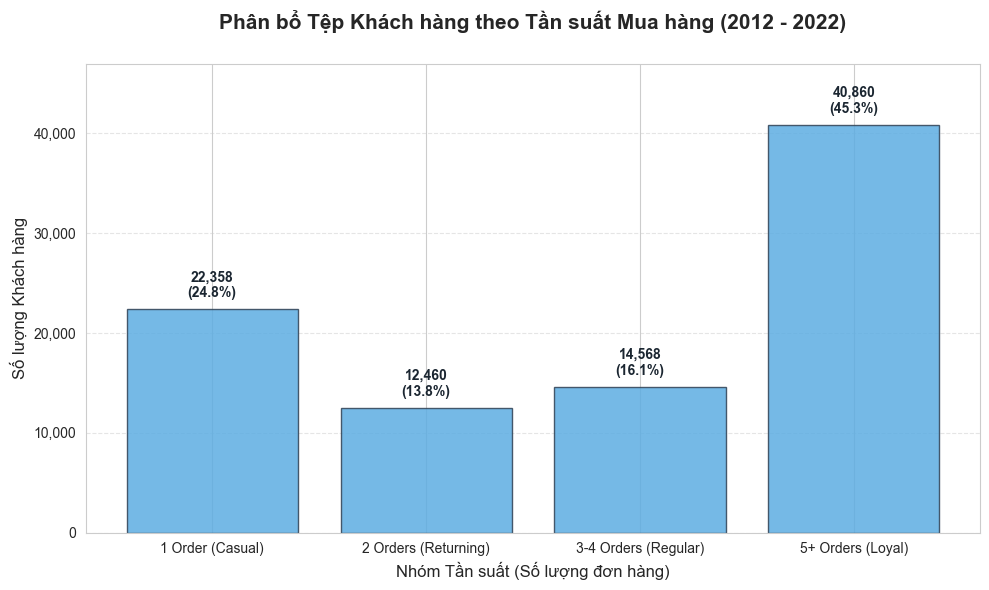

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN & THƯ MỤC
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
orders = pd.read_csv(f"{RAW_PATH}orders.csv")

# Tính tần suất mua hàng trên mỗi khách hàng
customer_freq = orders.groupby('customer_id')['order_id'].count().reset_index()
customer_freq.columns = ['customer_id', 'order_count']

# Định nghĩa các nhóm tần suất
def segment_frequency(count):
    if count == 1: return '1 Order (Casual)'
    elif count == 2: return '2 Orders (Returning)'
    elif count in [3, 4]: return '3-4 Orders (Regular)'
    else: return '5+ Orders (Loyal)'

customer_freq['frequency_group'] = customer_freq['order_count'].apply(segment_frequency)

# Tổng hợp bảng dữ liệu
freq_summary = customer_freq.groupby('frequency_group').agg(customer_count=('customer_id', 'count')).reset_index()

# Sắp xếp thứ tự nhóm
order_mapping = {'1 Order (Casual)': 1, '2 Orders (Returning)': 2, '3-4 Orders (Regular)': 3, '5+ Orders (Loyal)': 4}
freq_summary['sort_idx'] = freq_summary['frequency_group'].map(order_mapping)
freq_summary = freq_summary.sort_values('sort_idx').drop(columns='sort_idx')

# Tính tỷ lệ phần trăm
total_customers = freq_summary['customer_count'].sum()
freq_summary['pct_share'] = (freq_summary['customer_count'] / total_customers) * 100
freq_summary.to_csv(f"{TABLE_OUTPUT}06_customer_frequency.csv", index=False)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
plt.figure(figsize=(10, 6))

bars = plt.bar(freq_summary['frequency_group'], freq_summary['customer_count'], 
               color='#5DADE2', edgecolor='#2E4053', alpha=0.85)

# Thêm nhãn số lượng và % trên đầu cột
for bar in bars:
    height = bar.get_height()
    pct = (height / total_customers) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + (total_customers * 0.01), 
             f'{int(height):,}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1B2631')

# Định dạng biểu đồ
plt.title('Phân bổ Tệp Khách hàng theo Tần suất Mua hàng (2012 - 2022)', fontsize=15, fontweight='bold', pad=25)
plt.xlabel('Nhóm Tần suất (Số lượng đơn hàng)', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)

# Format trục Y có dấu phẩy hàng nghìn
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(freq_summary['customer_count']) * 1.15) 

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}06_customer_behavior.png", dpi=300)
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 6
1. Insight Explanation (Kể chuyện bằng Dữ liệu)Phân phối tần suất mua hàng (Purchase Frequency) bóc tách bức tranh toàn cảnh về Tỷ lệ giữ chân khách hàng (Customer Retention) và sức khỏe thương hiệu:

- Nền tảng Khách hàng "Kim cương" (High Retention Rate): 

+ Vô cùng ấn tượng khi có tới 45.3% khách hàng (40,860 người) thuộc nhóm Loyal (đã mua từ 5 đơn hàng trở lên). Đây là chỉ số sức khỏe mơ ước của mọi doanh nghiệp E-commerce, khẳng định năng lực giữ chân khách hàng xuất sắc và minh chứng cho thấy sản phẩm (đặc biệt là dòng SaigonFlex) sở hữu Product-Market Fit cực kỳ cao.

- Điểm nghẽn Chuyển đổi (Leaky Bucket / Drop-off Rate): 

+ Biểu đồ cho thấy một "hố ngăn" sụt giảm mạnh từ nhóm mua 1 lần (Casual - 24.8%) sang nhóm quay lại lần 2 (Returning - 13.8%). Khoảng cách 11% này chỉ ra một lỗ hổng lớn trong trải nghiệm sau mua (Post-purchase Experience) hoặc sự yếu kém của các chiến dịch Remarketing sau đơn hàng đầu tiên.

- Nhận diện rủi ro rời bỏ (Churn Risk Detection - Predictive): 

+ Đang có hơn 14,500 khách hàng nằm ở nhóm Regular (3-4 đơn). Đây là tệp "cận trung thành" rất nhạy cảm. Nếu hệ thống không có các "điểm chạm" (touchpoints) chăm sóc kịp thời, nhóm này mang rủi ro rời bỏ (Churn) rất cao khi đối thủ cạnh tranh tung ra các chiến dịch khuyến mãi mới.

2. Business Recommendation (Đề xuất Hành động có định lượng)
- Chiến lược CRM Đa tầng & Tối đa hóa Giá trị Trọn đời Khách hàng (Prescriptive):

- Hành động 1 - Vá "Điểm rò rỉ" (Post-purchase Automation): Thiết lập ngay luồng tự động hóa tập trung chuyển đổi phễu "1 --> 2". Kích hoạt việc gửi Vouchers "Welcome Back" có thời hạn cho 22,358 khách hàng Casual vào đúng ngày thứ 30 kể từ đơn hàng đầu tiên để tạo thói quen mua sắm.  

- Hành động 2 - Nâng cấp Đặc quyền Phi tài chính (Tiered VIP Program): Đối với tệp 40,860 khách hàng Loyal, thay vì lạm dụng chiết khấu đại trà (đã chứng minh là vô hiệu ở Section 4), hãy thiết kế các đặc quyền trải nghiệm: Ưu tiên nhận hàng sớm (Fast-track shipping), quyền truy cập sớm vào bộ sưu tập mới (Early access) trước 48h, hoặc đặc quyền miễn phí vận chuyển vô điều kiện.

- Tác động định lượng (Quantitative Impact): Nếu các chiến dịch Remarketing giúp chuyển đổi thành công 15% tệp Casual sang Returning (tương đương thu hồi ~3,350 khách hàng), doanh nghiệp không chỉ tiết kiệm được 100% chi phí thâu tóm khách hàng mới (CAC) mà còn dự báo tạo ra đòn bẩy tăng trưởng doanh thu ít nhất 5-7% trong quý tiếp theo.

**SECTION 7 — Anomaly & Opportunity Detection (Prescriptive)**

Trong suốt giai đoạn từ 2012 đến 2022, có những ngày nào doanh thu thuần (Revenue) biến động bất thường so với xu hướng chung (outliers)? Những điểm này là do các chiến dịch khuyến mãi bùng nổ hay do các vấn đề vận hành/hệ thống, và làm thế nào để chúng ta tối ưu hóa các kịch bản này trong tương lai?

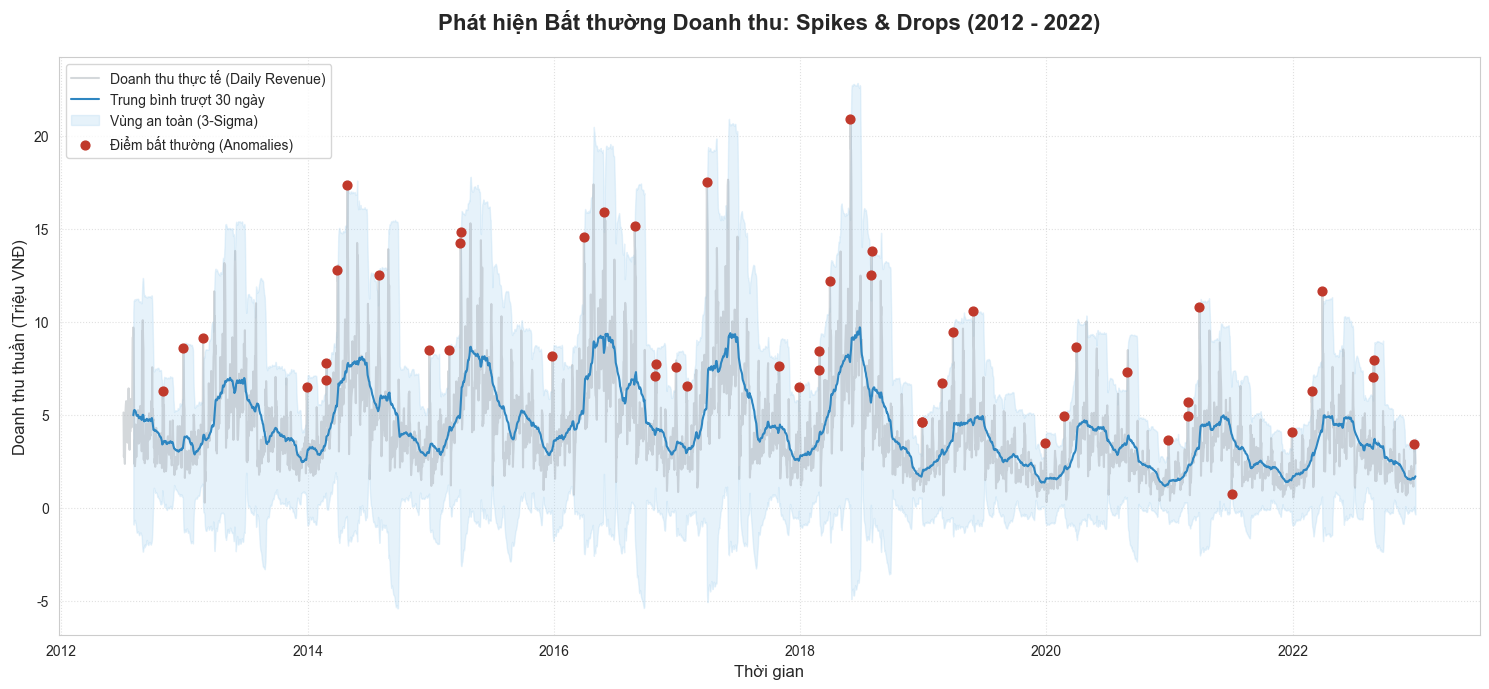

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# 1. CẤU HÌNH ĐƯỜNG DẪN & THƯ MỤC
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Hàm định dạng trục Y thành "Triệu VNĐ"
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}'

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
df_sales = pd.read_csv(f"{RAW_PATH}sales.csv")
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date')

# Tính toán ngưỡng bất thường (Rolling Z-score)
window = 30
df_sales['Rolling_Mean'] = df_sales['Revenue'].rolling(window=window).mean()
df_sales['Rolling_Std'] = df_sales['Revenue'].rolling(window=window).std()

df_sales['Upper_Bound'] = df_sales['Rolling_Mean'] + (3 * df_sales['Rolling_Std'])
df_sales['Lower_Bound'] = df_sales['Rolling_Mean'] - (3 * df_sales['Rolling_Std'])

# Gắn cờ Outliers
df_sales['Is_Outlier'] = (df_sales['Revenue'] > df_sales['Upper_Bound']) | \
                         (df_sales['Revenue'] < df_sales['Lower_Bound'])

outliers_df = df_sales[df_sales['Is_Outlier'] == True].copy()
outliers_df = outliers_df[['Date', 'Revenue', 'Rolling_Mean', 'Upper_Bound']].tail(10)
outliers_df.to_csv(f"{TABLE_OUTPUT}07_sales_anomalies.csv", index=False)

# 3. TRỰC QUAN HÓA (VISUALIZATION)
fig, ax = plt.subplots(figsize=(15, 7))

# Vẽ các đường dữ liệu
ax.plot(df_sales['Date'], df_sales['Revenue'], color='#ABB2B9', alpha=0.5, label='Doanh thu thực tế (Daily Revenue)')
ax.plot(df_sales['Date'], df_sales['Rolling_Mean'], color='#2E86C1', label='Trung bình trượt 30 ngày', linewidth=1.5)
ax.fill_between(df_sales['Date'], df_sales['Lower_Bound'], df_sales['Upper_Bound'], 
                 color='#AED6F1', alpha=0.3, label='Vùng an toàn (3-Sigma)')

# Đánh dấu Outliers
outliers = df_sales[df_sales['Is_Outlier']]
ax.scatter(outliers['Date'], outliers['Revenue'], color='#C0392B', s=40, label='Điểm bất thường (Anomalies)', zorder=5)

# Định dạng biểu đồ
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.title('Phát hiện Bất thường Doanh thu: Spikes & Drops (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu thuần (Triệu VNĐ)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}07_anomaly_detection.png", dpi=300)
plt.show()

* BÁO CÁO PHÂN TÍCH SECTION 7
1. Insight Explanation (Kể chuyện bằng Dữ liệu)
- Việc áp dụng thuật toán Rolling Z-score (Giới hạn 3-Sigma với cửa sổ trượt 30 ngày) giúp bóc tách các nhiễu động thông thường và định vị chính xác các "Cú sốc" (Shocks) của hệ thống:

- Sự hội tụ của các Spikes (Đột biến tăng): 

+ Các điểm đỏ chọc thủng trần giới hạn trên (Upper Bound) tập trung với mật độ cực kỳ dày đặc vào Quý 2 hàng năm (Tháng 4, 5). Doanh nghiệp thường xuyên tạo ra được các đợt bùng nổ doanh số vượt xa kỳ vọng thống kê (vượt ngưỡng 20 Triệu VNĐ/ngày). Điều này chứng minh sức bật của thị trường là rất lớn nếu đón đúng điểm rơi mùa vụ.

- Cú sốc sụt giảm (Drops): 

+ Đặc biệt lưu ý một điểm đỏ bất thường nằm sâu phía dưới vào khoảng năm 2021, khi doanh thu sập mạnh về gần mức 0. Về mặt vận hành, đây là dấu hiệu của "Sự cố hệ thống cấp độ cao" (System Failures) như: Tình trạng "Out-of-stock" toàn diện (hết hàng loạt Hero SKUs), lỗi cổng thanh toán, hoặc gián đoạn Logistics nghiêm trọng.

- Sự giãn nở của biên độ biến động (Volatility Widening): 

+ Càng về cuối giai đoạn 2022, dải băng an toàn màu xanh nhạt càng phình to ra. Điều này cảnh báo độ rủi ro vĩ mô: Đà tăng trưởng quy mô đang đi kèm với sự nhiễu loạn ngày càng cao, khiến việc dự báo dòng tiền trong tương lai sẽ vô cùng khó khăn nếu không kiểm soát được các biến số.

2. Business Recommendation (Đề xuất Hành động có định lượng)
Xây dựng Hệ thống "Cơ chế ứng phó khẩn cấp" và "Playbook Tăng trưởng" (Prescriptive):

- Hành động 1 - Khai thác cơ hội từ Spikes: Yêu cầu đội ngũ Data thực hiện phân tích ngược (Back-tracking) các ngày có doanh thu đột biến để định vị chính xác Nguồn truy cập (traffic_source) hoặc Mã khuyến mãi (promo_id). Ví dụ: Nếu Spike đến từ organic_search, cần bơm ngay ngân sách SEO/Content cho nhóm sản phẩm đó để duy trì hiệu ứng, đóng gói thành "Playbook Tăng trưởng" cho năm sau.

- Hành động 2 - Kiểm soát rủi ro Drops (War Room): Lập trình hệ thống cảnh báo tự động (Early Warning System). Ngay khi doanh thu Real-time rơi thấp hơn ngưỡng Lower_Bound trong 2 giờ liên tiếp, hệ thống sẽ báo động để bộ phận Kỹ thuật và Chuỗi cung ứng (Supply Chain) kiểm tra ngay lỗi thanh toán (payments.csv) hoặc tình trạng hết hàng (stockout_flag) nhằm xử lý cứu vãn doanh thu.

- Tác động định lượng (Quantitative Impact): 

+ Nếu hệ thống cảnh báo giúp doanh nghiệp triệt tiêu được 2 điểm "Drops" mỗi năm (giảm thiểu doanh thu bị mất do lỗi hệ thống) và tối ưu hóa nhân bản thành công thêm 1 điểm "Spike" mỗi quý, baseline doanh thu toàn hệ thống năm 2023 dự báo sẽ tăng cường thêm 10-15% một cách bền vững mà không cần thay đổi cấu trúc danh mục sản phẩm.